# Shows the quality of the simulations as a function of the number of arrivals per simulation run

## Load libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use('seaborn-v0_8')

## Load and process data

In [2]:
arrival_count_levels = [6, 7, 8, 9, 10]

values_plain = []
values_plot = []

exact_value = 320  # Calculated via Erlang-C formula

for arrival_count in arrival_count_levels:
    f = open(f"Statistics/WaitingTimes-{arrival_count}.txt", "r")
    values = [float(line.strip()) for line in f.readlines()]
    values_plain.append(values)
    values_plot.append([(value / exact_value - 1) * 100 for value in values])  # Values are in percent points

## Plot results

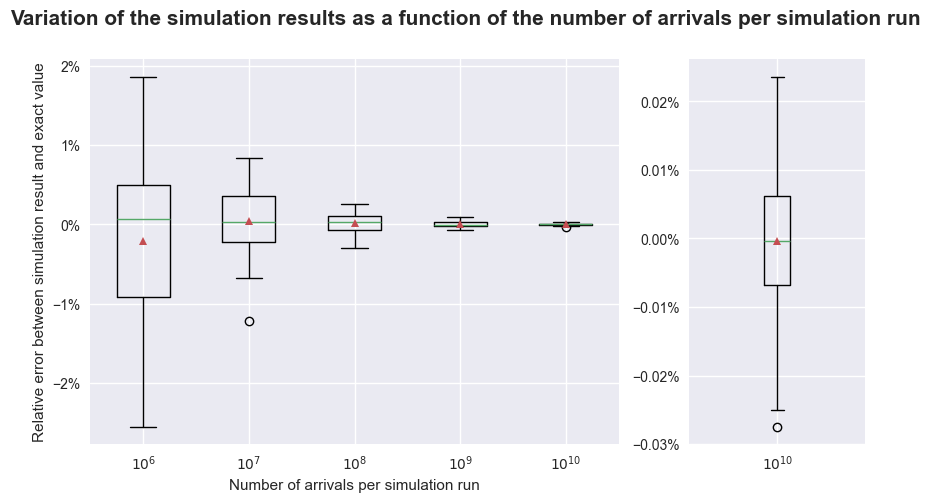

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [3, 1]}, figsize=(10,5))

ax1.boxplot(values_plot, tick_labels=["$10^{"+str(x)+"}$" for x in arrival_count_levels], showmeans=True)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax1.set_xlabel("Number of arrivals per simulation run")
ax1.set_ylabel("Relative error between simulation result and exact value")

ax2.boxplot(values_plot[4], tick_labels=["$10^{10}$"], showmeans=True)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

fig.suptitle("Variation of the simulation results as a function of the number of arrivals per simulation run", fontsize=15, fontweight="semibold")

# fig.savefig("images/RunCount-Boxplot.png", format="png", bbox_inches='tight', pad_inches=0)

# fig.savefig("images/BatchArithmeticAndMitigation-figure-results-RunCount-Boxplot.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

In [4]:
cv=[np.std(value)/np.mean(value) for value in values_plain]
min=[(np.min(value)-320)/320 for value in values_plain]
max=[(np.max(value)-320)/320 for value in values_plain]

for x,y,mi,mx in zip(arrival_count_levels,cv,min,max):
    print(f'n=10^{x}:\n  CV={y:.4f}\n  width={(mx-mi)*100:.3f}%')

n=10^6:
  CV=0.0102
  width=4.418%
n=10^7:
  CV=0.0039
  width=2.056%
n=10^8:
  CV=0.0012
  width=0.554%
n=10^9:
  CV=0.0004
  width=0.159%
n=10^10:
  CV=0.0001
  width=0.051%
